# Projet 9 — Lapage : Analyse e-commerce

**Période analysée :** mars 2021 – février 2023  
**Source :** 3 fichiers CSV (customers, products, transactions)

---

## Sommaire
1. [Nettoyage des données](#1-nettoyage)
2. [Analyses Annabelle — KPIs & indicateurs commerciaux](#2-annabelle)
3. [Analyses Julie — Corrélations comportementales](#3-julie)

In [124]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
from scipy import stats

DATA_DIR = Path("DAN-P6-donnees/DAN-P6-donnees")
CLEAN_DIR = Path("data_clean")
FIG_DIR = Path("figures")
CLEAN_DIR.mkdir(exist_ok=True)
FIG_DIR.mkdir(exist_ok=True)

print("Librairies chargées.")

Librairies chargées.


---
## 1. Nettoyage des données <a id='1-nettoyage'></a>

### 1.1 Customers

In [125]:
customers_raw = pd.read_csv(DATA_DIR / "customers.csv")
print(f"customers brut : {len(customers_raw):,} lignes")
print(customers_raw.dtypes)
customers_raw.head()

customers brut : 8,623 lignes
client_id      str
sex            str
birth        int64
dtype: object


,client_id,sex,birth
0,c_4410,f,1967
1,c_7839,f,1975
2,c_1699,f,1984
3,c_5961,f,1962
4,c_5320,m,1943


In [126]:
# Clé primaire
print(customers_raw["client_id"].nunique() == len(customers_raw))

# Doublons
customers_raw.duplicated().sum()

True


np.int64(0)

In [127]:
# Valeurs nulles
customers_raw.isnull().sum()

client_id    0
sex          0
birth        0
dtype: int64

In [128]:
# Valeurs abberantes
print(customers_raw["birth"].min())
print(customers_raw["birth"].max())

1929
2004


In [129]:
mask_test = customers_raw["client_id"].str.startswith("ct_")
print(f"clients test : {mask_test.sum()}")

customers = customers_raw[~mask_test].copy()
print(f"customers : {len(customers):,} lignes")

clients test : 2
customers : 8,621 lignes


### 1.2 Products

In [130]:
products_raw = pd.read_csv(DATA_DIR / "products.csv")
print(f"products brut : {len(products_raw):,} lignes")
print(products_raw.dtypes)
products_raw.head()

products brut : 3,287 lignes
id_prod        str
price      float64
categ        int64
dtype: object


,id_prod,price,categ
0,0_1421,19.99,0
1,0_1368,5.13,0
2,0_731,17.99,0
3,1_587,4.99,1
4,0_1507,3.99,0


In [131]:
# Clé primaire
print(products_raw["id_prod"].nunique() == len(products_raw))

# Doublons
products_raw.duplicated().sum()


True


np.int64(0)

In [132]:
# Valeurs nulles
products_raw.isnull().sum()

id_prod    0
price      0
categ      0
dtype: int64

In [133]:
# Valeurs abberantes
print(products_raw["price"].min())
print(products_raw["price"].max())

-1.0
300.0


In [134]:
mask_test = products_raw["id_prod"] == "T_0"
print(f"lignes test (T_0, prix=-1) : {mask_test.sum()}")

products = products_raw[~mask_test].copy()
print(f"products_clean : {len(products):,} lignes")
print(f"supprimés : {len(products_raw) - len(products)}")

lignes test (T_0, prix=-1) : 1
products_clean : 3,286 lignes
supprimés : 1


### 1.3 Transactions

In [135]:
transactions_raw = pd.read_csv(DATA_DIR / "transactions.csv")
transactions_raw["date"] = pd.to_datetime(transactions_raw["date"], errors="coerce")
print(f"transactions brut : {len(transactions_raw):,} lignes")
print(transactions_raw.dtypes)
transactions_raw.head()

transactions brut : 679,532 lignes
id_prod                  str
date          datetime64[us]
session_id               str
client_id                str
dtype: object


,id_prod,date,session_id,client_id
0,0_1518,2022-05-20 13:21:29.043970,s_211425,c_103
1,1_251,2022-02-02 07:55:19.149409,s_158752,c_8534
2,0_1277,2022-06-18 15:44:33.155329,s_225667,c_6714
3,2_209,2021-06-24 04:19:29.835891,s_52962,c_6941
4,0_1509,2023-01-11 08:22:08.194479,s_325227,c_4232


In [136]:
# Doublons
transactions_raw.duplicated().sum()

np.int64(198)

In [137]:
transactions_raw[transactions_raw.duplicated(keep=False)].sort_values(["session_id", "id_prod"])

,id_prod,date,session_id,client_id
3019,T_0,NaT,s_0,ct_0
5138,T_0,NaT,s_0,ct_0
9668,T_0,NaT,s_0,ct_1
10728,T_0,NaT,s_0,ct_0
15292,T_0,NaT,s_0,ct_0
...,...,...,...,...
657830,T_0,NaT,s_0,ct_0
662081,T_0,NaT,s_0,ct_1
670680,T_0,NaT,s_0,ct_1
671647,T_0,NaT,s_0,ct_1


In [138]:
mask_test = transactions_raw["client_id"].str.startswith("ct_")
print(f"clients test : {mask_test.sum()}")

transactions = transactions_raw[~mask_test].copy()
print(f"transactions : {len(transactions):,} lignes")

clients test : 200
transactions : 679,332 lignes


In [139]:
# Valeurs nulles
transactions_raw.isnull().sum()

id_prod         0
date          200
session_id      0
client_id       0
dtype: int64

In [140]:
# 1. Masquer les clients de test
mask_test = transactions_raw["client_id"].str.startswith("ct_")
print(f"lignes test : {mask_test.sum()}")
transactions = transactions_raw[~mask_test].copy()
print("lignes test masquées")

lignes test : 200
lignes test masquées


In [141]:
transactions.info()

<class 'pandas.DataFrame'>
Index: 679332 entries, 0 to 679531
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   id_prod     679332 non-null  str           
 1   date        679332 non-null  datetime64[us]
 2   session_id  679332 non-null  str           
 3   client_id   679332 non-null  str           
dtypes: datetime64[us](1), str(3)
memory usage: 38.5 MB


---
## 2. Analyses Annabelle — KPIs & indicateurs commerciaux <a id='2-annabelle'></a>

In [142]:
# Chargement des données nettoyées
tx = pd.read_csv(CLEAN_DIR / "transactions_clean.csv", parse_dates=["date"])
prod = pd.read_csv(CLEAN_DIR / "products_clean.csv")
cust = pd.read_csv(CLEAN_DIR / "customers_clean.csv")

In [143]:
df = tx.merge(prod, on="id_prod", how="left")
perdues = df[df["price"].isna()]

print(f"Lignes perdues : {len(perdues):,}")
print(f"Transactions valides : {len(tx):,}")
print(f"Clients actifs : {tx['client_id'].nunique():,}")
print(f"CA total : {df['price'].sum():,.0f} €")

Lignes perdues : 0
Transactions valides : 679,111
Clients actifs : 8,600
CA total : 11,853,729 €


### 2.1 CA mensuel

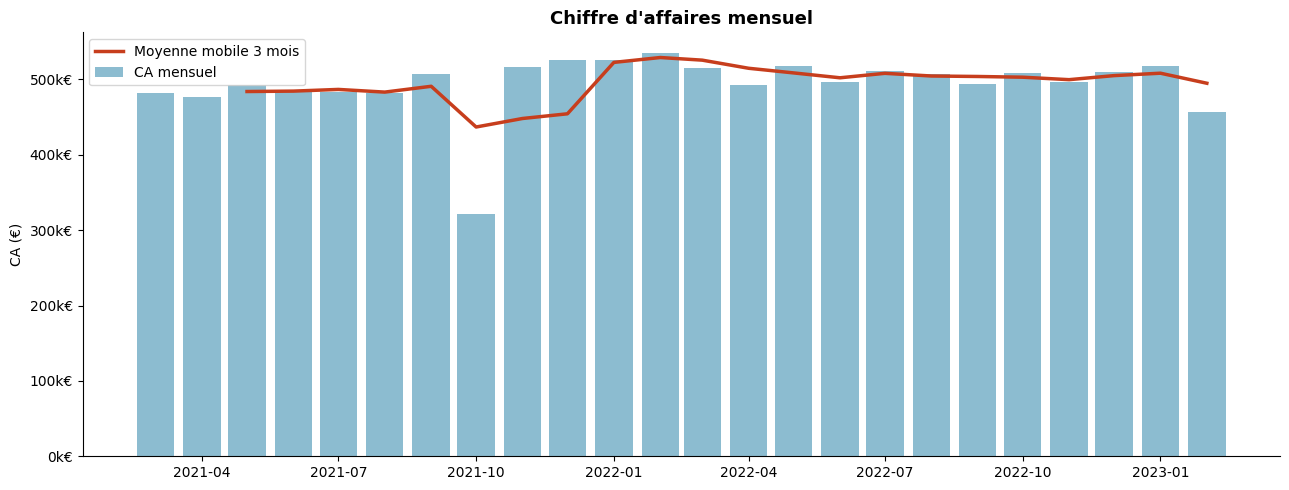

CA total : 11,853,729 €
CA moyen/mois : 493,905 €
Mois record : 2022-02
Mois creux : 2021-10


In [144]:
df["year_month"] = df["date"].dt.to_period("M")
monthly = df.groupby("year_month")["price"].sum().reset_index()
monthly["date"] = monthly["year_month"].dt.to_timestamp()
monthly["ma3"] = monthly["price"].rolling(3).mean()

fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(monthly["date"], monthly["price"], width=25, alpha=0.55, color="#2E86AB", label="CA mensuel")
ax.plot(monthly["date"], monthly["ma3"], color="#C73E1D", linewidth=2.5, label="Moyenne mobile 3 mois")
ax.set_title("Chiffre d'affaires mensuel", fontsize=13, fontweight="bold")
ax.set_ylabel("CA (€)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}k€"))
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "01_ca_mensuel.png")
plt.show()

print(f"CA total : {df['price'].sum():,.0f} €")
print(f"CA moyen/mois : {monthly['price'].mean():,.0f} €")
print(f"Mois record : {monthly.loc[monthly['price'].idxmax(), 'year_month']}")
print(f"Mois creux : {monthly.loc[monthly['price'].idxmin(), 'year_month']}")

### 2.2 CA par catégorie

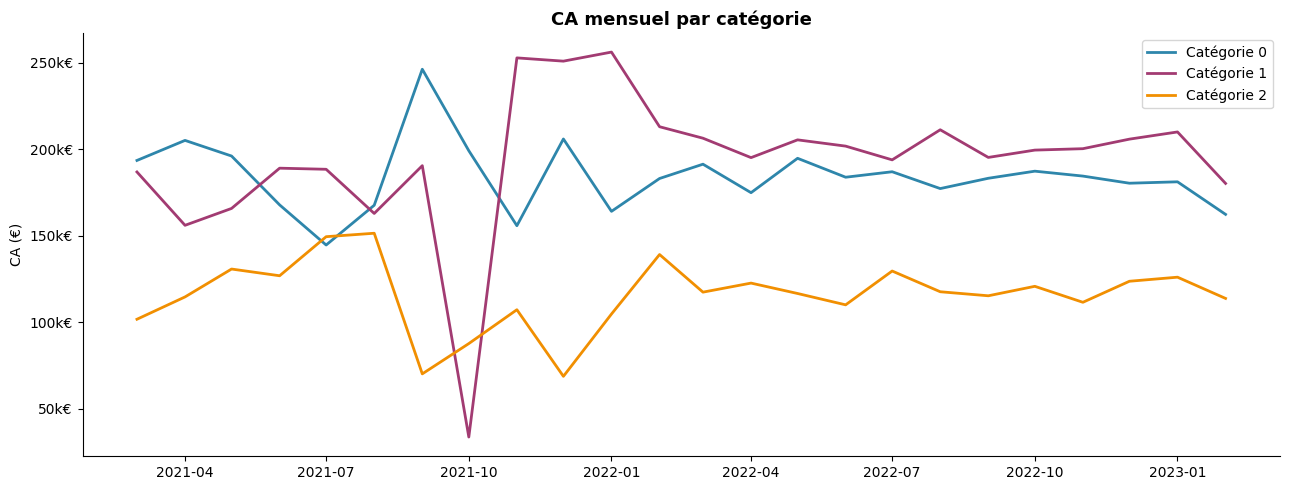

  Catégorie 0 : 4,419,731 € (37.3%)
  Catégorie 1 : 4,653,723 € (39.3%)
  Catégorie 2 : 2,780,275 € (23.5%)


In [147]:
df["categ"] = df["categ"].astype(str)
ca_categ_time = df.groupby(["year_month", "categ"])["price"].sum().unstack("categ", fill_value=0)
ca_categ_time.index = ca_categ_time.index.to_timestamp()

COLORS = ["#2E86AB", "#A23B72", "#F18F01"]

fig, ax = plt.subplots(figsize=(13, 5))
for i, col in enumerate(ca_categ_time.columns):
    ax.plot(ca_categ_time.index, ca_categ_time[col], label=f"Catégorie {col}", color=COLORS[i], linewidth=2)
ax.set_title("CA mensuel par catégorie", fontsize=13, fontweight="bold")
ax.set_ylabel("CA (€)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}k€"))
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "02_ca_par_categorie.png")
plt.show()

ca_total = df.groupby("categ")["price"].sum()
for c, v in ca_total.items():
    print(f"  Catégorie {c} : {v:,.0f} € ({v/ca_total.sum():.1%})")

### 2.3 Nombre de cliebts par mois

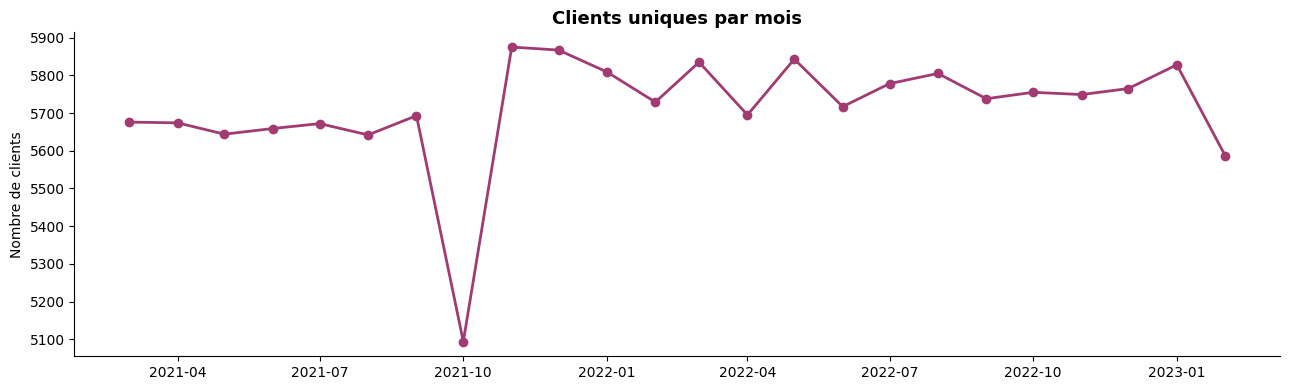

Moy. clients/mois : 5714
Max : 5875 (2021-11)
Min : 5094 (2021-10)


In [ ]:
clients_mois = tx.copy()
clients_mois["year_month"] = clients_mois["date"].dt.to_period("M")
clients_mois = clients_mois.groupby("year_month")["client_id"].nunique().reset_index()
clients_mois["date"] = clients_mois["year_month"].dt.to_timestamp()

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(clients_mois["date"], clients_mois["client_id"], marker="o", color="#A23B72", linewidth=2)
ax.set_title("Clients uniques par mois", fontsize=13, fontweight="bold")
ax.set_ylabel("Nombre de clients")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig(FIG_DIR / "03_clients_par_mois.png")
plt.show()

print(f"Moyenne clients/mois : {clients_mois['client_id'].mean():.0f}")
print(f"Max : {clients_mois['client_id'].max()} ({clients_mois.loc[clients_mois['client_id'].idxmax(), 'year_month']})")
print(f"Min : {clients_mois['client_id'].min()} ({clients_mois.loc[clients_mois['client_id'].idxmin(), 'year_month']})")

### 2.4 Nombre de transactions par mois

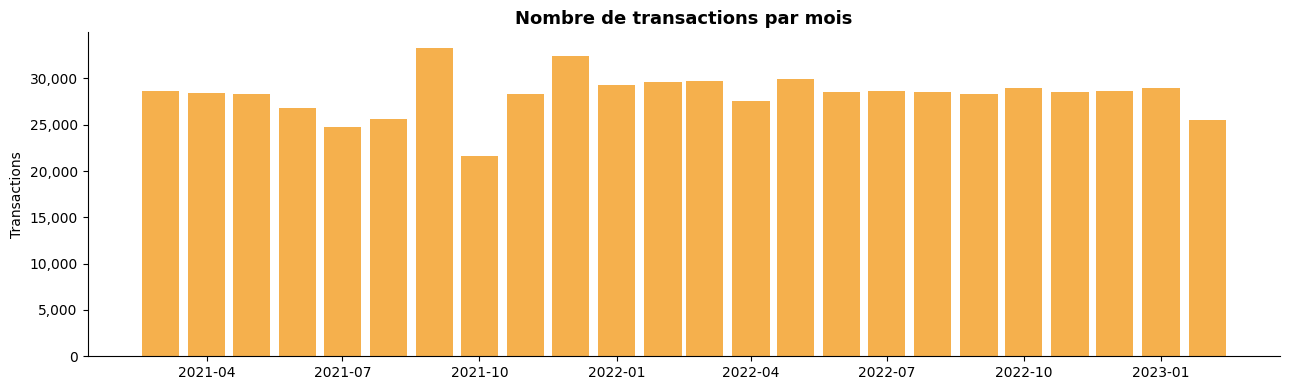

Total transactions : 679,111
Moy./mois : 28,296
Mois record : 2021-09 (33,314)


In [ ]:
tx_mois = tx.copy()
tx_mois["year_month"] = tx_mois["date"].dt.to_period("M")
tx_mois = tx_mois.groupby("year_month").size().reset_index(name="n")
tx_mois["date"] = tx_mois["year_month"].dt.to_timestamp()

fig, ax = plt.subplots(figsize=(13, 4))
ax.bar(tx_mois["date"], tx_mois["n"], width=25, alpha=0.7, color="#F18F01")
ax.set_title("Nombre de transactions par mois", fontsize=13, fontweight="bold")
ax.set_ylabel("Transactions")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig(FIG_DIR / "04_transactions_par_mois.png")
plt.show()

print(f"Total transactions année : {tx_mois['n'].sum():,}")
print(f"Moyenne/mois : {tx_mois['n'].mean():,.0f}")
print(f"Mois record : {tx_mois.loc[tx_mois['n'].idxmax(), 'year_month']} ({tx_mois['n'].max():,})")

### 2.5 Références distinctes vendues

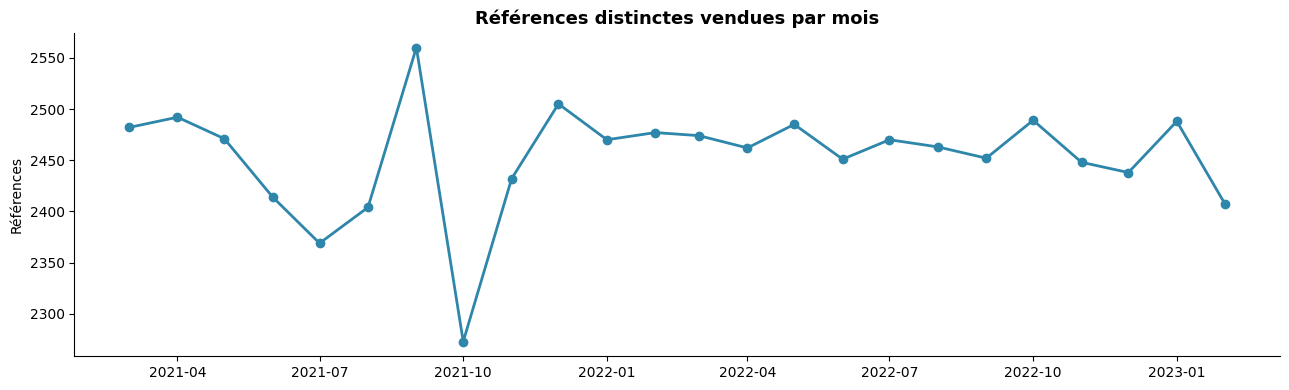

Moyenne références/mois : 2453
Max : 2560 (2021-09)
Min : 2273 (2021-10)

Produits vendus total/mois (moyenne) : 28296


In [148]:
refs_mois = tx.copy()
refs_mois["year_month"] = refs_mois["date"].dt.to_period("M")
refs_mois = refs_mois.groupby("year_month")["id_prod"].agg(
    n="nunique",
    total="count"
).reset_index()
refs_mois["date"] = refs_mois["year_month"].dt.to_timestamp()

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(refs_mois["date"], refs_mois["n"], marker="o", color="#2E86AB", linewidth=2)
ax.set_title("Références distinctes vendues par mois", fontsize=13, fontweight="bold")
ax.set_ylabel("Références")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig(FIG_DIR / "05_references_par_mois.png")
plt.show()

print(f"Moyenne références/mois : {refs_mois['n'].mean():.0f}")
print(f"Max : {refs_mois['n'].max()} ({refs_mois.loc[refs_mois['n'].idxmax(), 'year_month']})")
print(f"Min : {refs_mois['n'].min()} ({refs_mois.loc[refs_mois['n'].idxmin(), 'year_month']})")
print(f"\nProduits vendus total/mois (moyenne) : {refs_mois['total'].mean():.0f}")

### 2.6 Top 10 / Flop 10 produits

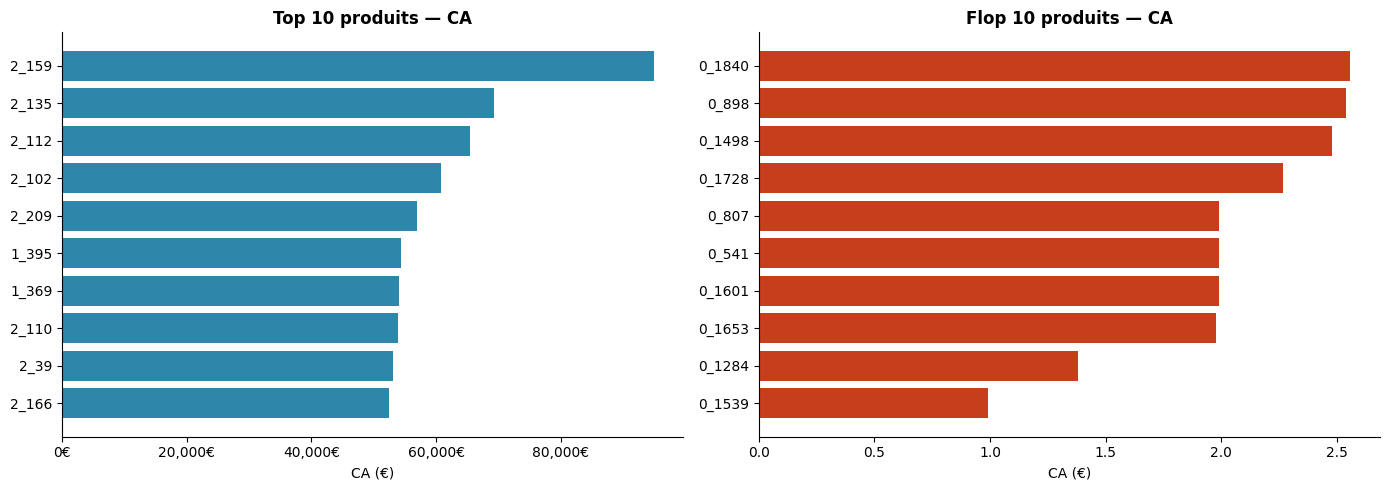

Top 10 :
               ca  ventes
id_prod                  
2_159    94893.50     650
2_135    69334.95    1005
2_112    65407.76     968
2_102    60736.78    1027
2_209    56971.86     814
1_395    54356.25    1875
1_369    54025.48    2252
2_110    53846.25     865
2_39     53060.85     915
2_166    52449.12     228


In [ ]:
ca_prod = df.groupby("id_prod")["price"].agg(ca="sum", ventes="count").sort_values("ca", ascending=False)
top10 = ca_prod.head(10)
flop10 = ca_prod.tail(10).sort_values("ca")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(top10.index[::-1], top10["ca"][::-1], color="#2E86AB")
axes[0].set_title("Top 10 produits — CA", fontweight="bold")
axes[0].set_xlabel("CA (€)")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}€"))
axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False)

axes[1].barh(flop10.index, flop10["ca"], color="#C73E1D")
axes[1].set_title("Flop 10 produits — CA", fontweight="bold")
axes[1].set_xlabel("CA (€)")
axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig(FIG_DIR / "06_top_flop_produits.png")
plt.show()

print("Top 10 :")
print(top10.to_string())

### 2.7 Répartition CA par catégorie

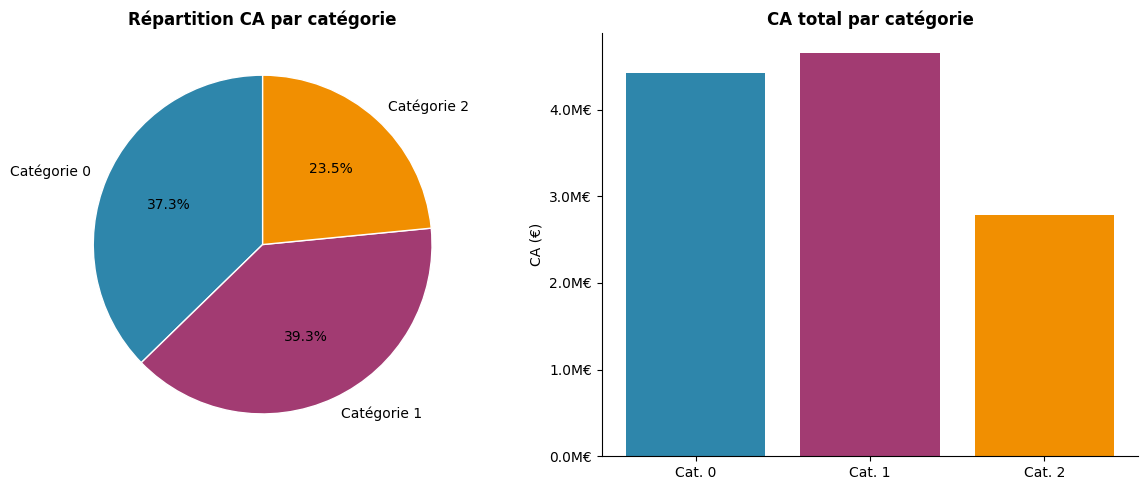

  Catégorie 0 : 4,419,731 € (37.3%)
  Catégorie 1 : 4,653,723 € (39.3%)
  Catégorie 2 : 2,780,275 € (23.5%)


In [ ]:
ca_categ = df.groupby("categ")["price"].sum().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].pie(
    ca_categ,
    labels=[f"Catégorie {c}" for c in ca_categ.index],
    autopct="%1.1f%%",
    colors=COLORS,
    startangle=90,
    wedgeprops={"edgecolor": "white"},
)
axes[0].set_title("Répartition CA par catégorie", fontweight="bold")

axes[1].bar([f"Cat. {c}" for c in ca_categ.index], ca_categ.values, color=COLORS)
axes[1].set_title("CA total par catégorie", fontweight="bold")
axes[1].set_ylabel("CA (€)")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1_000_000:.1f}M€"))
axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig(FIG_DIR / "07_repartition_categorie.png")
plt.show()

for c, v in ca_categ.items():
    print(f"  Catégorie {c} : {v:,.0f} € ({v/ca_categ.sum():.1%})")

### 2.8 CA BtoB (proxy : clients à fort volume)

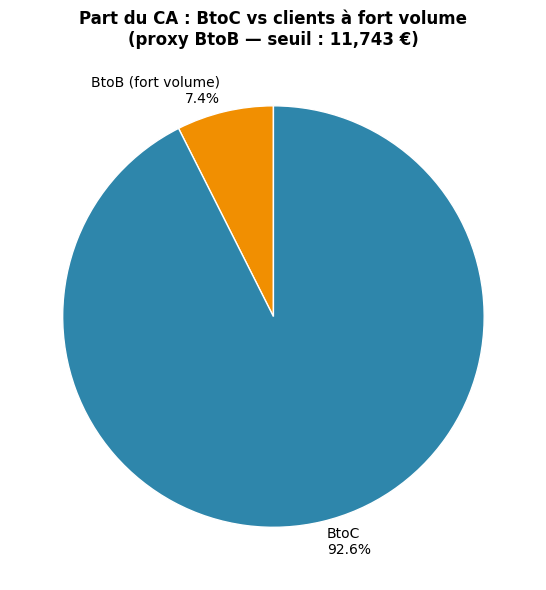

Seuil BtoB (moy + 2σ) : 11,743 €
Clients BtoB proxy    : 4 (0.0% des clients)
CA BtoB               : 881,031 €
CA BtoC               : 10,972,698 €


In [ ]:
ca_client = df.groupby("client_id")["price"].sum()
seuil = ca_client.mean() + 2 * ca_client.std()
btob_ids = ca_client[ca_client >= seuil].index

df["segment"] = df["client_id"].apply(lambda x: "BtoB (fort volume)" if x in btob_ids else "BtoC")
ca_segments = df.groupby("segment")["price"].sum()

fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(
    ca_segments,
    labels=[f"{label}\n{val/ca_segments.sum():.1%}" for label, val in ca_segments.items()],
    colors=["#F18F01", "#2E86AB"],
    startangle=90,
    wedgeprops={"edgecolor": "white"},
)
ax.set_title(
    f"Part du CA : BtoC vs clients à fort volume\n(proxy BtoB — seuil : {seuil:,.0f} €)",
    fontweight="bold",
)
plt.tight_layout()
plt.savefig(FIG_DIR / "08_ca_btob.png")
plt.show()

print(f"Seuil BtoB (moy + 2σ) : {seuil:,.0f} €")
print(f"Clients BtoB proxy    : {len(btob_ids)} ({len(btob_ids)/len(ca_client):.1%} des clients)")
print(f"CA BtoB               : {ca_segments.get('BtoB (fort volume)', 0):,.0f} €")
print(f"CA BtoC               : {ca_segments.get('BtoC', 0):,.0f} €")

### 2.9 Courbe de Lorenz — concentration du CA

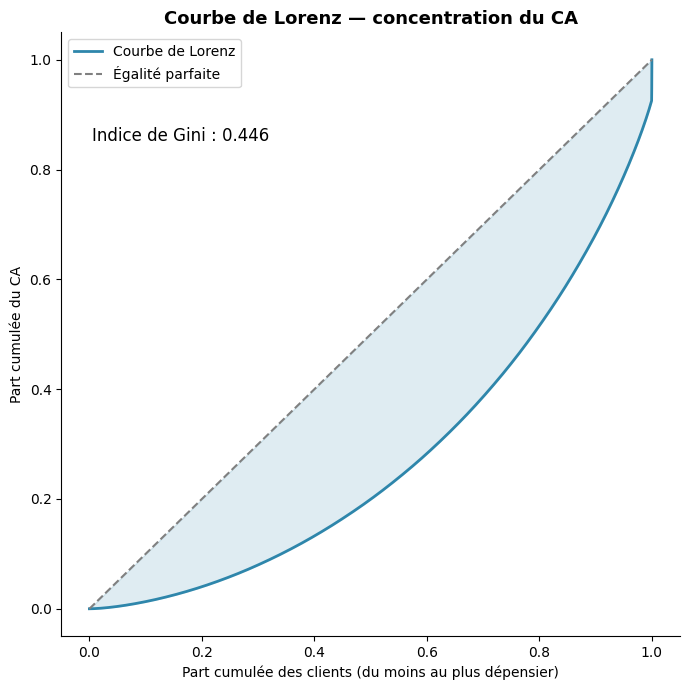

Indice de Gini : 0.446
Les 20% des clients les plus dépensiers représentent 48.4% du CA


In [ ]:
ca_client_sorted = df.groupby("client_id")["price"].sum().sort_values()
x = np.linspace(0, 1, len(ca_client_sorted))
y = ca_client_sorted.cumsum() / ca_client_sorted.sum()
gini = float(1 - 2 * np.trapezoid(y, x))

fig, ax = plt.subplots(figsize=(7, 7))
ax.plot(x, y.values, color="#2E86AB", linewidth=2, label="Courbe de Lorenz")
ax.plot([0, 1], [0, 1], "--", color="gray", linewidth=1.5, label="Égalité parfaite")
ax.fill_between(x, y.values, x, alpha=0.15, color="#2E86AB")
ax.set_xlabel("Part cumulée des clients (du moins au plus dépensier)")
ax.set_ylabel("Part cumulée du CA")
ax.set_title("Courbe de Lorenz — concentration du CA", fontsize=13, fontweight="bold")
ax.text(0.05, 0.82, f"Indice de Gini : {gini:.3f}", transform=ax.transAxes, fontsize=12)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "09_lorenz.png")
plt.show()

print(f"Indice de Gini : {gini:.3f}")
p20 = float(y.iloc[int(len(y) * 0.8)])
print(f"Les 20% des clients les plus dépensiers représentent {1 - p20:.1%} du CA")

---
## 3. Analyses Julie — Corrélations comportementales <a id='3-julie'></a>

In [ ]:
df_full = tx.merge(prod, on="id_prod").merge(cust, on="client_id")
df_full["categ"] = df_full["categ"].astype(str)
df_full["age"] = 2023 - df_full["birth"]
print(f"Dataset complet : {len(df_full):,} lignes")

Dataset complet : 679,111 lignes


### 3.1 Genre ↔ Catégorie achetée (Chi²)

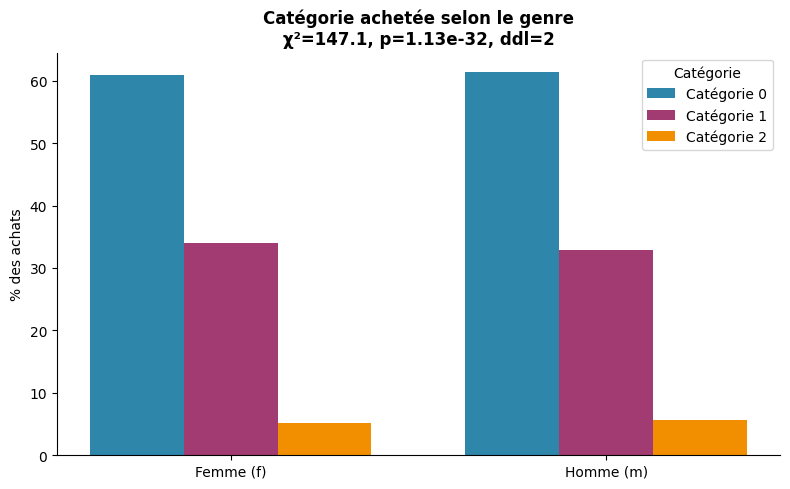

Chi² = 147.12, p = 0.0000, ddl = 2
→ Lien significatif (p < 0.05)

Répartition % par genre :
categ     0     1    2
sex                   
f      60.9  34.0  5.1
m      61.4  32.9  5.6


In [ ]:
genre_categ = df_full.groupby(["sex", "categ"]).size().unstack("categ", fill_value=0)
genre_categ_pct = genre_categ.div(genre_categ.sum(axis=1), axis=0) * 100
chi2_val, p_val, dof, _ = stats.chi2_contingency(genre_categ)

fig, ax = plt.subplots(figsize=(8, 5))
x_pos = np.arange(len(genre_categ_pct.index))
width = 0.25
for i, col in enumerate(genre_categ_pct.columns):
    ax.bar(x_pos + i * width, genre_categ_pct[col], width, label=f"Catégorie {col}", color=COLORS[i])
ax.set_xticks(x_pos + width)
ax.set_xticklabels(["Femme (f)", "Homme (m)"])
ax.set_title(
    f"Catégorie achetée selon le genre\nχ²={chi2_val:.1f}, p={p_val:.2e}, ddl={dof}",
    fontsize=12, fontweight="bold",
)
ax.set_ylabel("% des achats")
ax.legend(title="Catégorie")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig(FIG_DIR / "10_genre_categorie.png")
plt.show()

print(f"Chi² = {chi2_val:.2f}, p = {p_val:.4f}, ddl = {dof}")
print("→", "Lien significatif (p < 0.05)" if p_val < 0.05 else "Pas de lien significatif (p ≥ 0.05)")
print("\nRépartition % par genre :")
print(genre_categ_pct.round(1).to_string())

### 3.2 Âge ↔ CA total (Pearson)

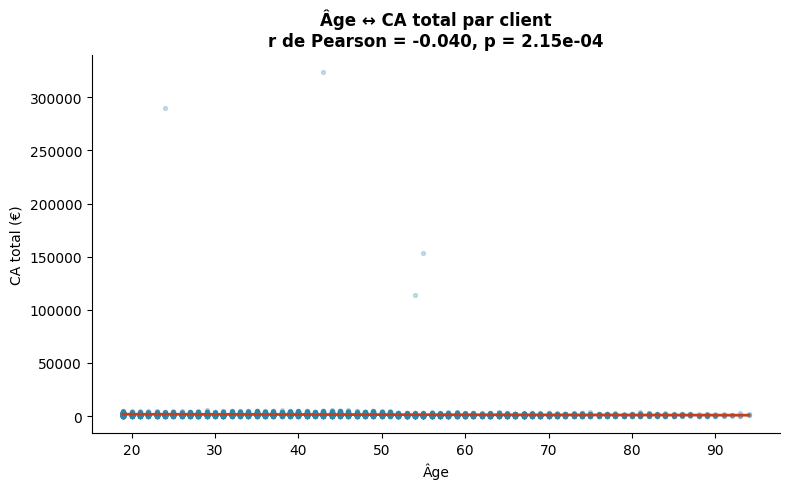

r de Pearson = -0.040, p = 0.0002
→ Corrélation significative (p < 0.05)
Pente : +-12.23 € de CA par année d'âge supplémentaire


In [ ]:
client_stats = df_full.groupby("client_id").agg(
    ca_total=("price", "sum"),
    age=("age", "first")
).reset_index()

r, p_val = stats.pearsonr(client_stats["age"], client_stats["ca_total"])
m, b = np.polyfit(client_stats["age"], client_stats["ca_total"], 1)
x_line = np.array([client_stats["age"].min(), client_stats["age"].max()])

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(client_stats["age"], client_stats["ca_total"], alpha=0.25, s=8, color="#2E86AB")
ax.plot(x_line, m * x_line + b, color="#C73E1D", linewidth=2)
ax.set_title(f"Âge ↔ CA total par client\nr de Pearson = {r:.3f}, p = {p_val:.2e}", fontsize=12, fontweight="bold")
ax.set_xlabel("Âge")
ax.set_ylabel("CA total (€)")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig(FIG_DIR / "11_age_ca_total.png")
plt.show()

print(f"r de Pearson = {r:.3f}, p = {p_val:.4f}")
print("→", "Corrélation significative (p < 0.05)" if p_val < 0.05 else "Pas de corrélation significative (p ≥ 0.05)")
print(f"Pente : +{m:.2f} € de CA par année d'âge supplémentaire")

### 3.3 Âge ↔ Fréquence d'achat (Pearson)

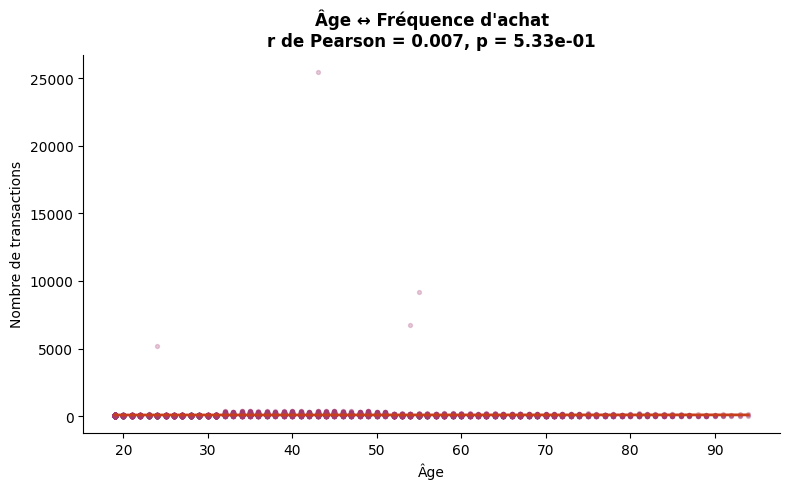

r de Pearson = 0.007, p = 0.5331
→ Pas de corrélation significative (p ≥ 0.05)
Moy. transactions par client : 79.0


In [ ]:
client_freq = df_full.groupby("client_id").agg(
    nb_transactions=("id_prod", "count"),
    age=("age", "first")
).reset_index()

r, p_val = stats.pearsonr(client_freq["age"], client_freq["nb_transactions"])
m, b = np.polyfit(client_freq["age"], client_freq["nb_transactions"], 1)
x_line = np.array([client_freq["age"].min(), client_freq["age"].max()])

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(client_freq["age"], client_freq["nb_transactions"], alpha=0.25, s=8, color="#A23B72")
ax.plot(x_line, m * x_line + b, color="#C73E1D", linewidth=2)
ax.set_title(f"Âge ↔ Fréquence d'achat\nr de Pearson = {r:.3f}, p = {p_val:.2e}", fontsize=12, fontweight="bold")
ax.set_xlabel("Âge")
ax.set_ylabel("Nombre de transactions")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig(FIG_DIR / "12_age_frequence.png")
plt.show()

print(f"r de Pearson = {r:.3f}, p = {p_val:.4f}")
print("→", "Corrélation significative (p < 0.05)" if p_val < 0.05 else "Pas de corrélation significative (p ≥ 0.05)")
print(f"Moy. transactions par client : {client_freq['nb_transactions'].mean():.1f}")

### 3.4 Âge ↔ Panier moyen (Pearson)

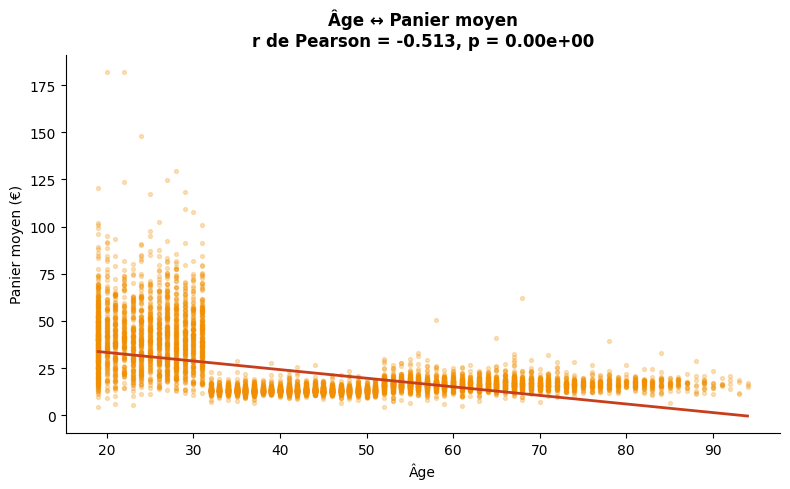

r de Pearson = -0.513, p = 0.0000
→ Corrélation significative (p < 0.05)
Panier moyen global : 22.02 €


In [ ]:
client_panier = df_full.groupby("client_id").agg(
    panier_moyen=("price", "mean"),
    age=("age", "first")
).reset_index()

r, p_val = stats.pearsonr(client_panier["age"], client_panier["panier_moyen"])
m, b = np.polyfit(client_panier["age"], client_panier["panier_moyen"], 1)
x_line = np.array([client_panier["age"].min(), client_panier["age"].max()])

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(client_panier["age"], client_panier["panier_moyen"], alpha=0.25, s=8, color="#F18F01")
ax.plot(x_line, m * x_line + b, color="#C73E1D", linewidth=2)
ax.set_title(f"Âge ↔ Panier moyen\nr de Pearson = {r:.3f}, p = {p_val:.2e}", fontsize=12, fontweight="bold")
ax.set_xlabel("Âge")
ax.set_ylabel("Panier moyen (€)")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig(FIG_DIR / "13_age_panier_moyen.png")
plt.show()

print(f"r de Pearson = {r:.3f}, p = {p_val:.4f}")
print("→", "Corrélation significative (p < 0.05)" if p_val < 0.05 else "Pas de corrélation significative (p ≥ 0.05)")
print(f"Panier moyen global : {client_panier['panier_moyen'].mean():.2f} €")

### 3.5 Tranche d'âge ↔ Catégorie achetée (Chi²)

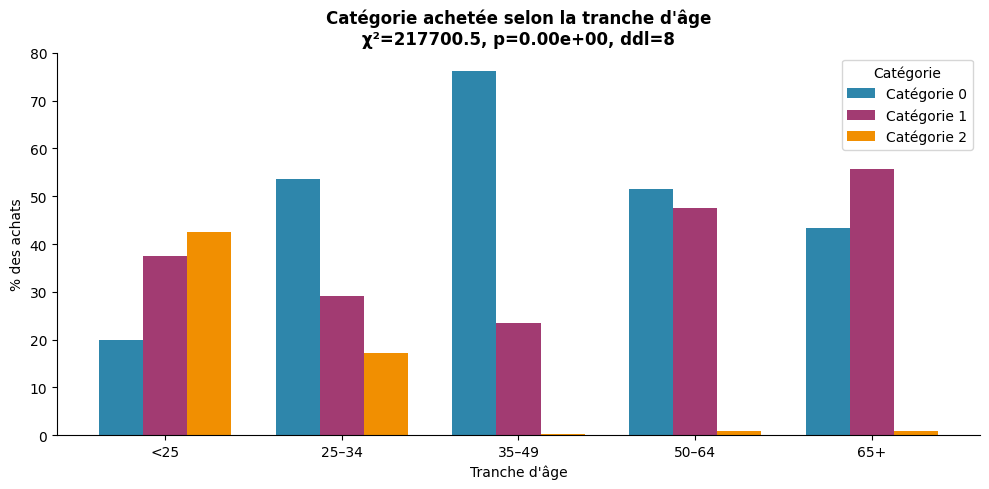

Chi² = 217700.54, p = 0.0000, ddl = 8
→ Lien significatif (p < 0.05)

Répartition % par tranche d'âge :
categ           0     1     2
tranche_age                  
<25          20.0  37.5  42.5
25–34        53.7  29.1  17.2
35–49        76.2  23.4   0.3
50–64        51.4  47.6   0.9
65+          43.4  55.7   0.9


In [ ]:
age_bins = [0, 25, 35, 50, 65, 110]
age_labels = ["<25", "25–34", "35–49", "50–64", "65+"]
df_full["tranche_age"] = pd.cut(df_full["age"], bins=age_bins, labels=age_labels, right=False)

age_categ = df_full.groupby(["tranche_age", "categ"], observed=True).size().unstack("categ", fill_value=0)
age_categ_pct = age_categ.div(age_categ.sum(axis=1), axis=0) * 100
chi2_val, p_val, dof, _ = stats.chi2_contingency(age_categ)

fig, ax = plt.subplots(figsize=(10, 5))
x_pos = np.arange(len(age_categ_pct.index))
width = 0.25
for i, col in enumerate(age_categ_pct.columns):
    ax.bar(x_pos + i * width, age_categ_pct[col], width, label=f"Catégorie {col}", color=COLORS[i])
ax.set_xticks(x_pos + width)
ax.set_xticklabels(age_labels)
ax.set_title(
    f"Catégorie achetée selon la tranche d'âge\nχ²={chi2_val:.1f}, p={p_val:.2e}, ddl={dof}",
    fontsize=12, fontweight="bold",
)
ax.set_ylabel("% des achats")
ax.set_xlabel("Tranche d'âge")
ax.legend(title="Catégorie")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig(FIG_DIR / "14_age_categorie.png")
plt.show()

print(f"Chi² = {chi2_val:.2f}, p = {p_val:.4f}, ddl = {dof}")
print("→", "Lien significatif (p < 0.05)" if p_val < 0.05 else "Pas de lien significatif (p ≥ 0.05)")
print("\nRépartition % par tranche d'âge :")
print(age_categ_pct.round(1).to_string())